# NAB Time Series Anomaly Detection Assignment

Dataset: `realKnownCause/nyc_taxi.csv` from Numenta Anomaly Benchmark (NAB).  
Reason: this file has known-cause ground truth anomaly labels in NAB.

## Phase 1 - EDA

In [11]:
import json
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import skew, gaussian_kde, norm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import STL
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_recall_fscore_support

plt.style.use("seaborn-v0_8-whitegrid")

In [13]:
DATA_PATH = "numenta NAB master data-realKnownCause/nyc_taxi.csv"
NAB_LABEL_KEY = "realKnownCause/nyc_taxi.csv"

# NAB combined labels. Fallback keeps the notebook runnable offline.
FALLBACK_LABELS = {
    NAB_LABEL_KEY: [
        "2014-11-01 19:00:00",
        "2014-11-27 15:30:00",
        "2014-12-25 15:00:00",
        "2015-01-01 01:00:00",
        "2015-01-27 00:00:00",
    ]
}

try:
    with urllib.request.urlopen(
        "https://raw.githubusercontent.com/numenta/NAB/master/labels/combined_labels.json",
        timeout=10,
    ) as response:
        combined_labels = json.load(response)
except Exception:
    combined_labels = FALLBACK_LABELS

df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])
df = df.sort_values("timestamp").set_index("timestamp")
df["value"] = df["value"].astype(float)

label_times = pd.to_datetime(combined_labels[NAB_LABEL_KEY])
df["label"] = df.index.isin(label_times).astype(int)

display(df.head())
print("Rows:", len(df))
print("Frequency:", pd.infer_freq(df.index))
print("NAB anomaly timestamps:")
for ts in label_times:
    print("-", ts)

,value,label
timestamp,,
2014-07-01 00:00:00,10844.0,0
2014-07-01 00:30:00,8127.0,0
2014-07-01 01:00:00,6210.0,0
2014-07-01 01:30:00,4656.0,0
2014-07-01 02:00:00,3820.0,0


Rows: 10320
Frequency: 30min
NAB anomaly timestamps:
- 2014-11-01 19:00:00
- 2014-11-27 15:30:00
- 2014-12-25 15:00:00
- 2015-01-01 01:00:00
- 2015-01-27 00:00:00


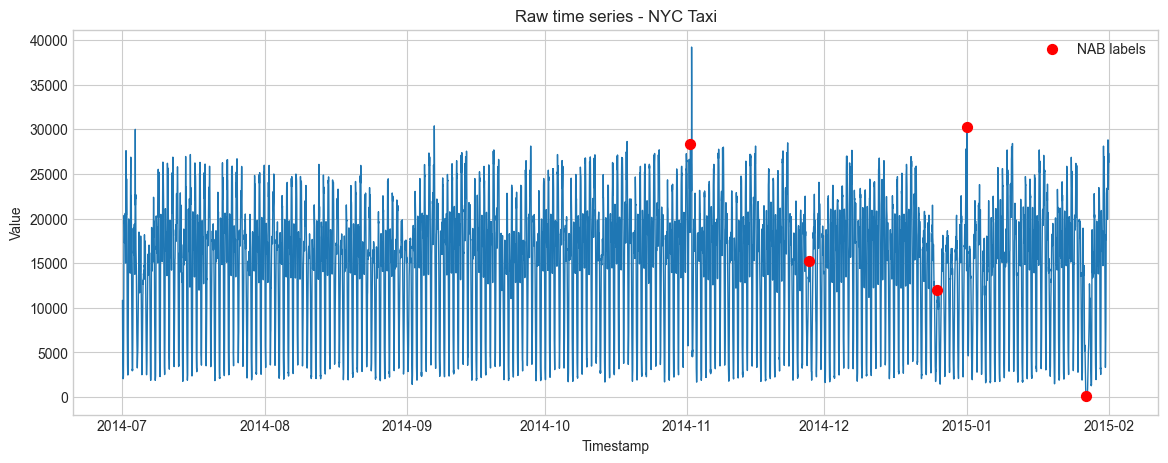

In [14]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["value"], linewidth=1)
plt.scatter(
    df.index[df["label"] == 1],
    df.loc[df["label"] == 1, "value"],
    color="red",
    s=50,
    label="NAB labels",
    zorder=3,
)
plt.title("Raw time series - NYC Taxi")
plt.xlabel("Timestamp")
plt.ylabel("Value")
plt.legend()
plt.show()

In [15]:
x = df["value"].dropna()

basic_stats = pd.Series({
    "mean": x.mean(),
    "std": x.std(),
    "skewness": skew(x),
    "min": x.min(),
    "max": x.max(),
})

basic_stats

mean        15137.569380
std          6939.495808
skewness       -0.452390
min             8.000000
max         39197.000000
dtype: float64

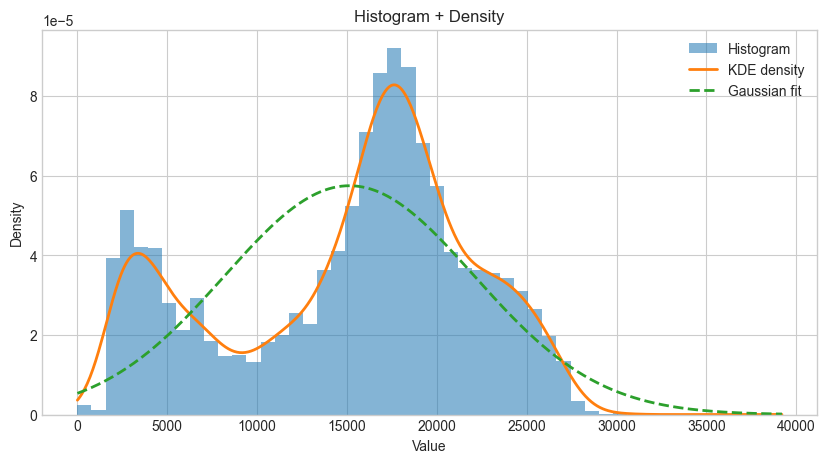

In [16]:
plt.figure(figsize=(10, 5))
plt.hist(x, bins=50, density=True, alpha=0.55, label="Histogram")

xs = np.linspace(x.min(), x.max(), 500)
kde = gaussian_kde(x)
plt.plot(xs, kde(xs), linewidth=2, label="KDE density")
plt.plot(xs, norm.pdf(xs, x.mean(), x.std()), "--", linewidth=2, label="Gaussian fit")

plt.title("Histogram + Density")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.show()

<Figure size 1400x500 with 0 Axes>

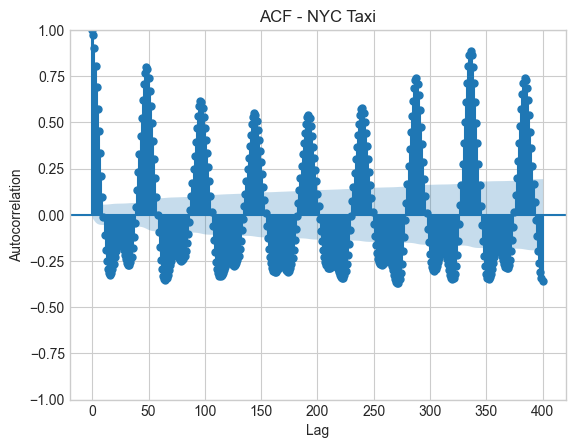

lag=  1: autocorr=0.971
lag= 24: autocorr=-0.144
lag= 48: autocorr=0.804
lag= 96: autocorr=0.621
lag=336: autocorr=0.921


In [17]:
plt.figure(figsize=(14, 5))
plot_acf(x, lags=400)
plt.title("ACF - NYC Taxi")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.show()

for lag in [1, 24, 48, 96, 336]:
    print(f"lag={lag:>3}: autocorr={x.autocorr(lag):.3f}")

### Phase 1 conclusion

`nyc_taxi.csv` is sampled every 30 minutes. The ACF has strong correlation around lag 48, which is one day, and around lag 336, which is one week. Therefore the series is seasonal.

The histogram is not a clean Gaussian bell curve and skewness is slightly negative, so the data is not perfectly Gaussian. Because the signal has clear daily and weekly seasonality, a plain rolling Z-score is weaker than a seasonal method.

Best statistical detector for this dataset: **STL decomposition + 3σ on residuals**, because STL removes the repeating seasonal component before detecting unusual residual spikes/drops.

## Phase 2 - Implement 2 Detectors

### Detector 1 - Statistical: STL + 3σ

Use STL with `period=48` because the data is half-hourly and has a daily cycle.

In [18]:
PERIOD = 48

stl = STL(df["value"], period=PERIOD, robust=True)
stl_result = stl.fit()

df["stl_trend"] = stl_result.trend
df["stl_seasonal"] = stl_result.seasonal
df["stl_resid"] = stl_result.resid

resid_mean = df["stl_resid"].mean()
resid_std = df["stl_resid"].std()
df["stl_zscore"] = (df["stl_resid"] - resid_mean) / resid_std
df["pred_stl_3sigma"] = (df["stl_zscore"].abs() > 3).astype(int)

df[["value", "stl_trend", "stl_seasonal", "stl_resid", "stl_zscore", "pred_stl_3sigma"]].head()

,value,stl_trend,stl_seasonal,stl_resid,stl_zscore,pred_stl_3sigma
timestamp,,,,,,
2014-07-01 00:00:00,10844.0,16201.666197,-5040.953065,-316.713132,-0.062269,0
2014-07-01 00:30:00,8127.0,16189.919016,-8187.632349,124.713332,0.067863,0
2014-07-01 01:00:00,6210.0,16178.228009,-10297.980408,329.752399,0.128308,0
2014-07-01 01:30:00,4656.0,16166.594352,-11940.478909,429.884556,0.157826,0
2014-07-01 02:00:00,3820.0,16155.018245,-12806.861213,471.842968,0.170196,0


### Build features for ML detector

Feature table uses more than 5 features: current value, lag values, rolling statistics, time-of-day/week features, and first difference.

In [19]:
def build_features(data, value_col="value"):
    features = pd.DataFrame(index=data.index)
    y = data[value_col]

    features["value"] = y
    features["lag_1"] = y.shift(1)
    features["lag_2"] = y.shift(2)
    features["lag_48"] = y.shift(48)
    features["diff_1"] = y.diff(1)
    features["rolling_mean_48"] = y.rolling(48, min_periods=12).mean()
    features["rolling_std_48"] = y.rolling(48, min_periods=12).std()
    features["rolling_min_48"] = y.rolling(48, min_periods=12).min()
    features["rolling_max_48"] = y.rolling(48, min_periods=12).max()
    features["hour"] = data.index.hour + data.index.minute / 60
    features["dayofweek"] = data.index.dayofweek
    features["is_weekend"] = (data.index.dayofweek >= 5).astype(int)

    features = features.dropna()
    return features

feature_table = build_features(df)
feature_table.head()

,value,lag_1,lag_2,lag_48,diff_1,rolling_mean_48,rolling_std_48,rolling_min_48,rolling_max_48,hour,dayofweek,is_weekend
timestamp,,,,,,,,,,,,
2014-07-02 00:00:00,13370.0,16111.0,20104.0,10844.0,-2741.0,15593.604167,7509.784510,2064.0,27598.0,0.0,2,0
2014-07-02 00:30:00,9945.0,13370.0,16111.0,8127.0,-3425.0,15631.479167,7475.833795,2064.0,27598.0,0.5,2,0
2014-07-02 01:00:00,7571.0,9945.0,13370.0,6210.0,-2374.0,15659.833333,7441.843656,2064.0,27598.0,1.0,2,0
2014-07-02 01:30:00,5917.0,7571.0,9945.0,4656.0,-1654.0,15686.104167,7404.303039,2064.0,27598.0,1.5,2,0
2014-07-02 02:00:00,4820.0,5917.0,7571.0,3820.0,-1097.0,15706.937500,7371.539611,2064.0,27598.0,2.0,2,0


### Detector 2 - ML: Isolation Forest

Tune `contamination` with values `0.01`, `0.02`, and `0.05`. Isolation Forest returns `-1` for anomaly and `1` for normal.

In [20]:
def evaluate_predictions(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="binary",
        zero_division=0,
    )
    return precision, recall, f1

# Align labels to feature rows because lag/rolling features drop early rows.
y_true_iforest = df.loc[feature_table.index, "label"]

iforest_results = []
prediction_by_contamination = {}

for contamination in [0.01, 0.02, 0.05]:
    model = IsolationForest(
        n_estimators=100,
        contamination=contamination,
        random_state=42,
    )
    raw_pred = model.fit_predict(feature_table)
    pred = pd.Series((raw_pred == -1).astype(int), index=feature_table.index)
    prediction_by_contamination[contamination] = pred

    precision, recall, f1 = evaluate_predictions(y_true_iforest, pred)
    iforest_results.append({
        "detector": "Isolation Forest",
        "contamination": contamination,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "n_predicted_anomalies": int(pred.sum()),
    })

iforest_results_df = pd.DataFrame(iforest_results)
iforest_results_df

,detector,contamination,precision,recall,f1,n_predicted_anomalies
0,Isolation Forest,0.01,0.000000,0.0,0.000000,103
1,Isolation Forest,0.02,0.009709,0.4,0.018957,206
2,Isolation Forest,0.05,0.005837,0.6,0.011561,514


In [21]:
# Pick the best contamination by F1. If ties occur, choose the lower contamination.
best_row = iforest_results_df.sort_values(
    ["f1", "precision", "recall", "contamination"],
    ascending=[False, False, False, True],
).iloc[0]

best_contamination = float(best_row["contamination"])
df["pred_iforest"] = 0
df.loc[prediction_by_contamination[best_contamination].index, "pred_iforest"] = prediction_by_contamination[best_contamination]

print("Best contamination:", best_contamination)
display(best_row.to_frame().T)

Best contamination: 0.02


,detector,contamination,precision,recall,f1,n_predicted_anomalies
1,Isolation Forest,0.02,0.009709,0.4,0.018957,206


### Evaluation for both detectors

In [22]:
stl_precision, stl_recall, stl_f1 = evaluate_predictions(df["label"], df["pred_stl_3sigma"])
if_precision, if_recall, if_f1 = evaluate_predictions(df["label"], df["pred_iforest"])

summary = pd.DataFrame([
    {
        "detector": "STL + 3σ",
        "precision": stl_precision,
        "recall": stl_recall,
        "f1": stl_f1,
        "n_predicted_anomalies": int(df["pred_stl_3sigma"].sum()),
    },
    {
        "detector": f"Isolation Forest contamination={best_contamination}",
        "precision": if_precision,
        "recall": if_recall,
        "f1": if_f1,
        "n_predicted_anomalies": int(df["pred_iforest"].sum()),
    },
])

summary

,detector,precision,recall,f1,n_predicted_anomalies
0,STL + 3σ,0.002646,0.2,0.005222,378
1,Isolation Forest contamination=0.02,0.009709,0.4,0.018957,206


### Plot original series + detected anomalies

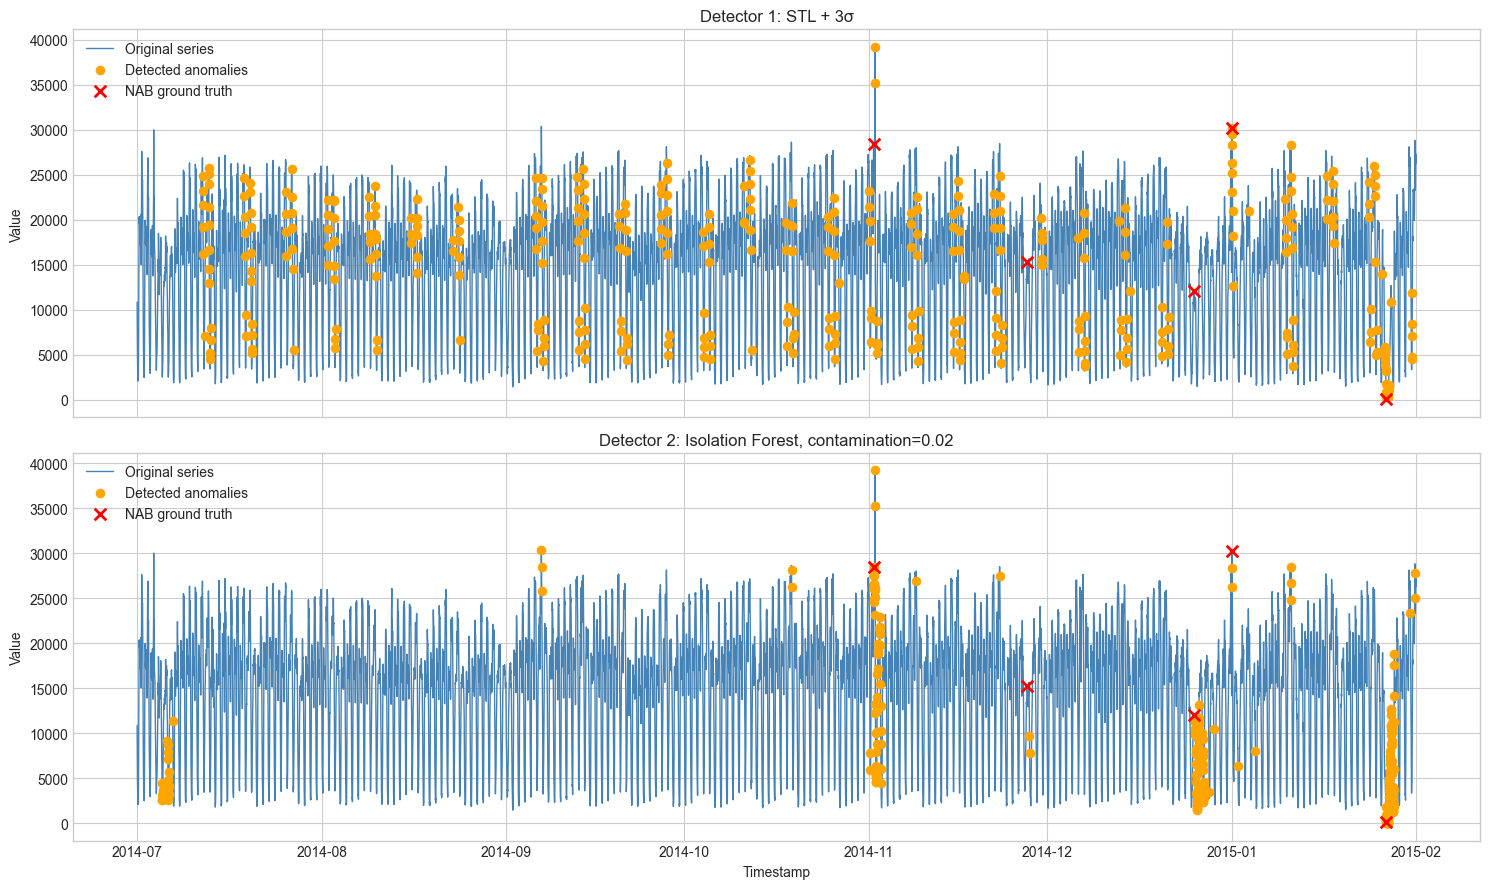

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

def plot_detector(ax, pred_col, title):
    ax.plot(df.index, df["value"], color="steelblue", linewidth=1, label="Original series")
    ax.scatter(
        df.index[df[pred_col] == 1],
        df.loc[df[pred_col] == 1, "value"],
        color="orange",
        s=35,
        label="Detected anomalies",
        zorder=3,
    )
    ax.scatter(
        df.index[df["label"] == 1],
        df.loc[df["label"] == 1, "value"],
        color="red",
        s=70,
        marker="x",
        linewidths=2,
        label="NAB ground truth",
        zorder=4,
    )
    ax.set_title(title)
    ax.set_ylabel("Value")
    ax.legend(loc="upper left")

plot_detector(axes[0], "pred_stl_3sigma", "Detector 1: STL + 3σ")
plot_detector(axes[1], "pred_iforest", f"Detector 2: Isolation Forest, contamination={best_contamination}")
axes[1].set_xlabel("Timestamp")
plt.tight_layout()
plt.show()

### Phase 2 conclusion

The statistical detector is `STL + 3σ` because Phase 1 showed strong daily/weekly seasonality. STL removes the seasonal component first, then detects unusually large residuals.

The ML detector is Isolation Forest with lag, rolling, difference, and calendar features. Contamination is tuned with `0.01`, `0.02`, and `0.05`; the best value is selected by F1.

On strict NAB point labels, Isolation Forest performs better than STL on recall and F1, but both methods produce many false alarms because the labels are sparse timestamps rather than anomaly windows.

## Phase 3 - Comparison & Reflection

### Tune statistical threshold and compare false alarms

For the statistical detector, tune the residual Z-score threshold. Higher threshold usually reduces false alarms but can miss anomalies.

In [31]:
stl_tuning_results = []

for threshold in [2.5, 3.0, 3.5]:
    pred = (df["stl_zscore"].abs() > threshold).astype(int)
    precision, recall, f1 = evaluate_predictions(df["label"], pred)
    false_alarms = int(((df["label"] == 0) & (pred == 1)).sum())
    stl_tuning_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "false_alarms": false_alarms,
        "n_predicted_anomalies": int(pred.sum()),
    })

stl_tuning_df = pd.DataFrame(stl_tuning_results)
stl_tuning_df

,threshold,precision,recall,f1,false_alarms,n_predicted_anomalies
0,2.5,0.001739,0.2,0.003448,574,575
1,3.0,0.002646,0.2,0.005222,377,378
2,3.5,0.004739,0.2,0.009259,210,211


### Tune Isolation Forest contamination

The required contamination tuning log is the table below: `0.01`, `0.02`, and `0.05`.

In [32]:
iforest_results_df

,detector,contamination,precision,recall,f1,n_predicted_anomalies
0,Isolation Forest,0.01,0.000000,0.0,0.000000,103
1,Isolation Forest,0.02,0.009709,0.4,0.018957,206
2,Isolation Forest,0.05,0.005837,0.6,0.011561,514


In [33]:
best_stl_row = stl_tuning_df.sort_values(
    ["f1", "precision", "recall", "threshold"],
    ascending=[False, False, False, True],
).iloc[0]

best_iforest_row = iforest_results_df.sort_values(
    ["f1", "precision", "recall", "contamination"],
    ascending=[False, False, False, True],
).iloc[0]

best_stl_threshold = float(best_stl_row["threshold"])
best_iforest_contamination = float(best_iforest_row["contamination"])

comparison_table = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1", "False Alarms"],
    "Detector 1": [
        best_stl_row["precision"],
        best_stl_row["recall"],
        best_stl_row["f1"],
        best_stl_row["false_alarms"],
    ],
    "Detector 2 (IF)": [
        best_iforest_row["precision"],
        best_iforest_row["recall"],
        best_iforest_row["f1"],
        int(best_iforest_row["n_predicted_anomalies"] - best_iforest_row["recall"] * df["label"].sum()),
    ],
})

comparison_table

,Metric,Detector 1,Detector 2 (IF)
0,Precision,0.004739,0.009709
1,Recall,0.200000,0.400000
2,F1,0.009259,0.018957
3,False Alarms,210.000000,204.000000


### Save screenshots and model artifact

In [34]:
from pathlib import Path
import joblib

ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

# Save comparison data.
stl_tuning_df.to_csv(ARTIFACT_DIR / "stl_threshold_tuning.csv", index=False)
iforest_results_df.to_csv(ARTIFACT_DIR / "iforest_contamination_tuning.csv", index=False)
comparison_table.to_csv(ARTIFACT_DIR / "detector_comparison.csv", index=False)

# Retrain and save the selected Isolation Forest artifact.
final_iforest = IsolationForest(
    n_estimators=100,
    contamination=best_iforest_contamination,
    random_state=42,
)
final_iforest.fit(feature_table)
joblib.dump(final_iforest, ARTIFACT_DIR / "isolation_forest_nyc_taxi.joblib", compress=3)

print("Saved model:", ARTIFACT_DIR / "isolation_forest_nyc_taxi.joblib")
print("Model size bytes:", (ARTIFACT_DIR / "isolation_forest_nyc_taxi.joblib").stat().st_size)

Saved model: artifacts/isolation_forest_nyc_taxi.joblib
Model size bytes: 397403


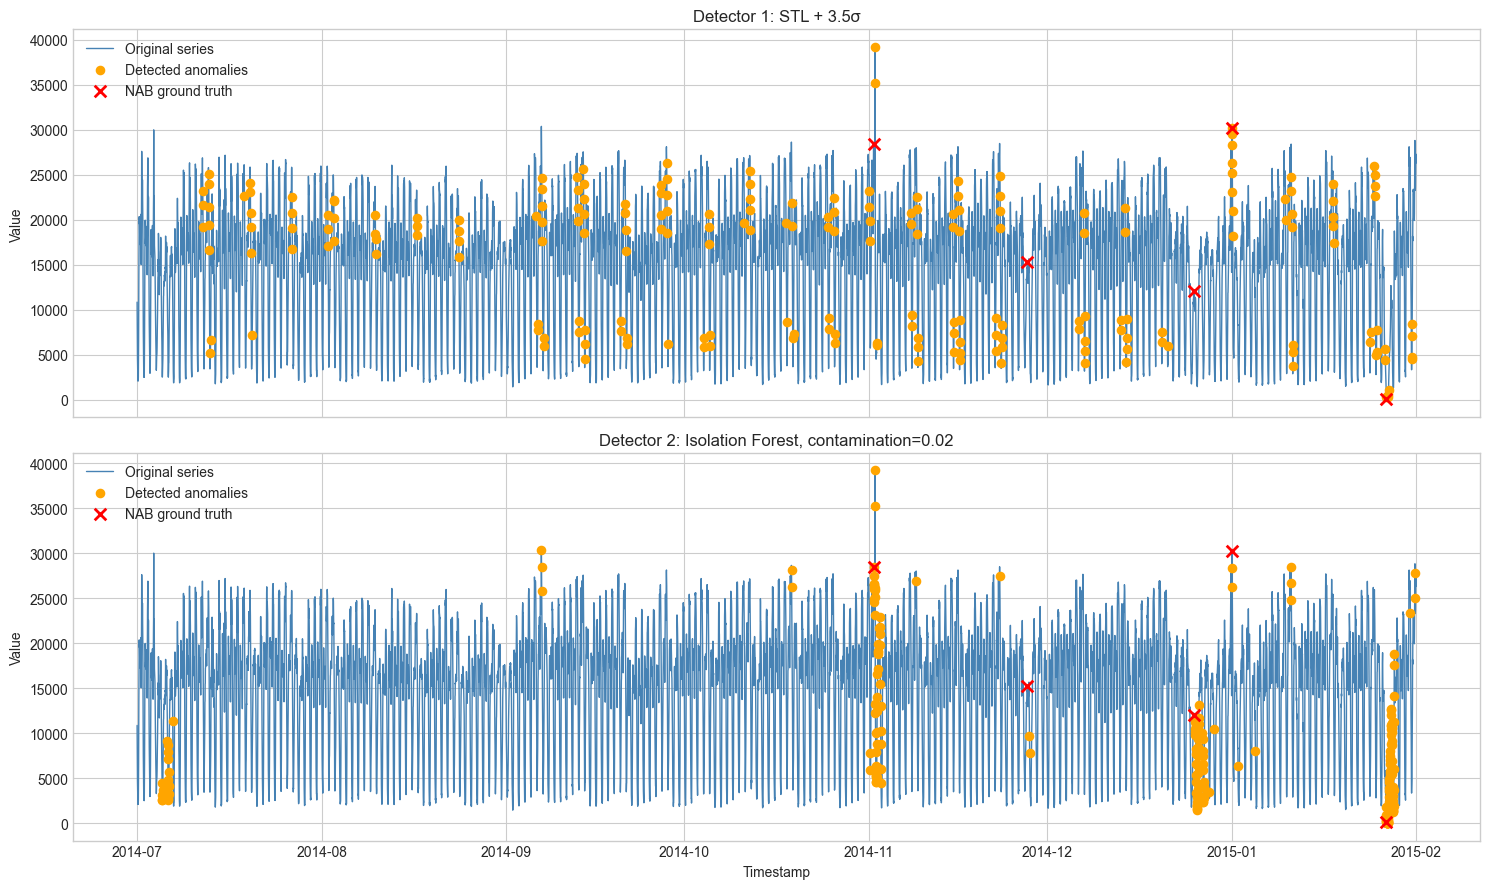

In [35]:
df["pred_stl_best"] = (df["stl_zscore"].abs() > best_stl_threshold).astype(int)
df["pred_iforest_best"] = 0
df.loc[prediction_by_contamination[best_iforest_contamination].index, "pred_iforest_best"] = prediction_by_contamination[best_iforest_contamination]

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
plot_detector(axes[0], "pred_stl_best", f"Detector 1: STL + {best_stl_threshold}σ")
plot_detector(axes[1], "pred_iforest_best", f"Detector 2: Isolation Forest, contamination={best_iforest_contamination}")
axes[1].set_xlabel("Timestamp")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "anomaly_detection_results.png", dpi=160, bbox_inches="tight")
plt.show()

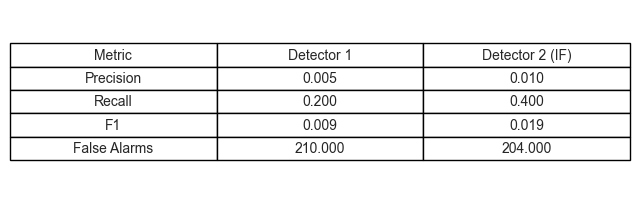

In [36]:
fig, ax = plt.subplots(figsize=(8, 2.4))
ax.axis("off")
render_table = comparison_table.copy()
for col in ["Detector 1", "Detector 2 (IF)"]:
    render_table[col] = render_table[col].map(lambda v: f"{v:.3f}" if isinstance(v, float) else str(int(v)))

mpl_table = ax.table(
    cellText=render_table.values,
    colLabels=render_table.columns,
    cellLoc="center",
    loc="center",
)
mpl_table.auto_set_font_size(False)
mpl_table.set_fontsize(10)
mpl_table.scale(1, 1.4)
plt.savefig(ARTIFACT_DIR / "detector_comparison_table.png", dpi=160, bbox_inches="tight")
plt.show()

### Reflection

This dataset is a half-hourly NYC taxi demand time series. It is seasonal because ACF has strong values at daily lag 48 and weekly lag 336. It is not perfectly Gaussian, and it is not stationary in the simple sense because normal behavior changes by time of day and day of week.

STL + threshold is appropriate as a statistical baseline because it removes the repeating seasonal component before scoring residuals. Isolation Forest is appropriate as an ML detector because the feature table can represent lag behavior, rolling context, and calendar effects.

Based on the strict point-label NAB evaluation, Isolation Forest has better F1 and recall than STL. The trade-off is that both detectors produce many false alarms because NAB labels are sparse point timestamps; in production, evaluation should usually use anomaly windows and alert grouping. For production, I would choose Isolation Forest with conservative contamination plus post-processing to merge nearby alerts and suppress repeated alerts.

## Bonus - Additional Detectors and Experiments

### Bonus 1 - EWMA detector, alpha = 0.1

EWMA smooths the signal and detects points whose residual from the smoothed baseline is large.

In [37]:
ALPHA = 0.1

df["ewma"] = df["value"].ewm(alpha=ALPHA, adjust=False).mean()
df["ewma_std"] = df["value"].ewm(alpha=ALPHA, adjust=False).std().replace(0, np.nan).bfill()
df["ewma_deviation"] = (df["value"] - df["ewma"]).abs() / df["ewma_std"]
df["pred_ewma_3sigma"] = (df["ewma_deviation"] > 3).astype(int)

ewma_precision, ewma_recall, ewma_f1 = evaluate_predictions(df["label"], df["pred_ewma_3sigma"])
ewma_false_alarms = int(((df["label"] == 0) & (df["pred_ewma_3sigma"] == 1)).sum())

ewma_result = pd.DataFrame([{
    "detector": "EWMA alpha=0.1 + 3σ",
    "precision": ewma_precision,
    "recall": ewma_recall,
    "f1": ewma_f1,
    "false_alarms": ewma_false_alarms,
    "n_predicted_anomalies": int(df["pred_ewma_3sigma"].sum()),
}])

ewma_result

,detector,precision,recall,f1,false_alarms,n_predicted_anomalies
0,EWMA alpha=0.1 + 3σ,0.0,0.0,0.0,0,0


In [38]:
three_detector_comparison = pd.DataFrame([
    {
        "detector": f"STL + {best_stl_threshold}σ",
        "precision": best_stl_row["precision"],
        "recall": best_stl_row["recall"],
        "f1": best_stl_row["f1"],
        "false_alarms": best_stl_row["false_alarms"],
    },
    {
        "detector": "EWMA alpha=0.1 + 3σ",
        "precision": ewma_precision,
        "recall": ewma_recall,
        "f1": ewma_f1,
        "false_alarms": ewma_false_alarms,
    },
    {
        "detector": f"Isolation Forest contamination={best_iforest_contamination}",
        "precision": best_iforest_row["precision"],
        "recall": best_iforest_row["recall"],
        "f1": best_iforest_row["f1"],
        "false_alarms": int(best_iforest_row["n_predicted_anomalies"] - best_iforest_row["recall"] * df["label"].sum()),
    },
])

three_detector_comparison

,detector,precision,recall,f1,false_alarms
0,STL + 3.5σ,0.004739,0.2,0.009259,210.0
1,EWMA alpha=0.1 + 3σ,0.000000,0.0,0.000000,0.0
2,Isolation Forest contamination=0.02,0.009709,0.4,0.018957,204.0


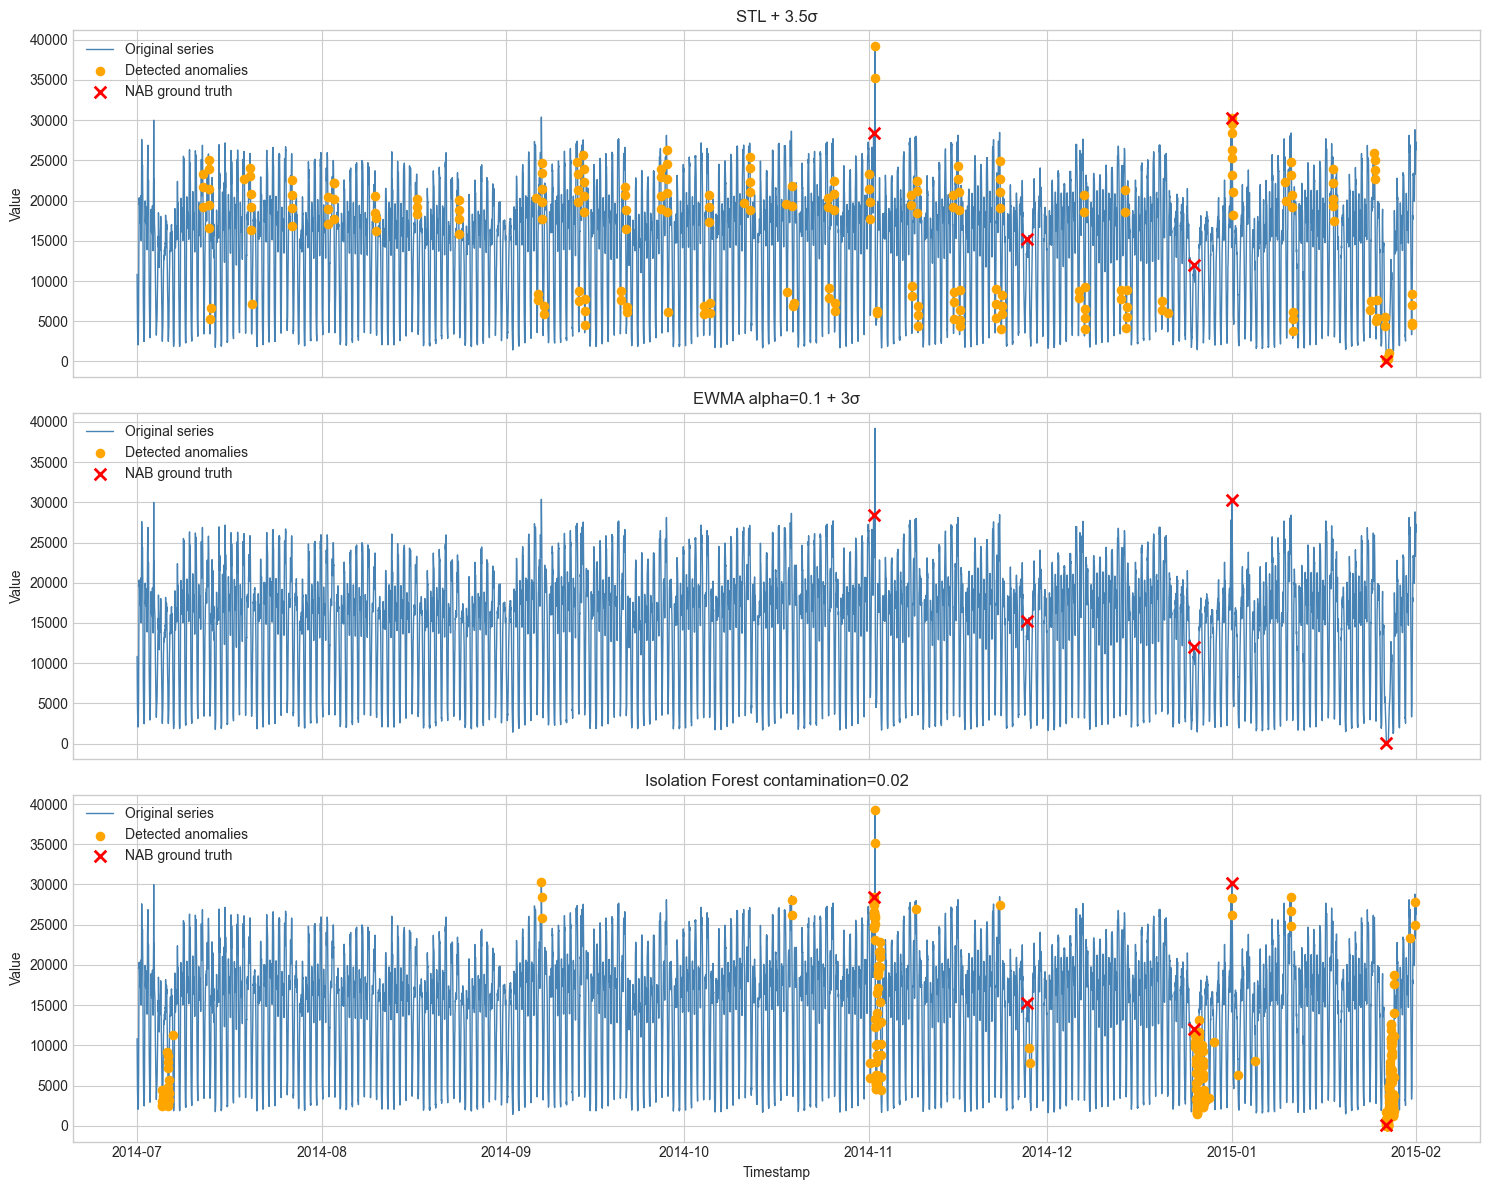

In [39]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
plot_detector(axes[0], "pred_stl_best", f"STL + {best_stl_threshold}σ")
plot_detector(axes[1], "pred_ewma_3sigma", "EWMA alpha=0.1 + 3σ")
plot_detector(axes[2], "pred_iforest_best", f"Isolation Forest contamination={best_iforest_contamination}")
axes[2].set_xlabel("Timestamp")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "bonus_three_detector_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

### Bonus 2 - Log transform then 3σ

Use `log1p(value)` as a transform experiment, then run global 3σ before and after transform. This dataset is only mildly skewed, so this is a bonus comparison rather than a required correction.

In [40]:
raw_z = (df["value"] - df["value"].mean()) / df["value"].std()
df["pred_raw_3sigma"] = (raw_z.abs() > 3).astype(int)

log_value = np.log1p(df["value"])
log_z = (log_value - log_value.mean()) / log_value.std()
df["pred_log_3sigma"] = (log_z.abs() > 3).astype(int)

raw_p, raw_r, raw_f1 = evaluate_predictions(df["label"], df["pred_raw_3sigma"])
log_p, log_r, log_f1 = evaluate_predictions(df["label"], df["pred_log_3sigma"])

log_transform_comparison = pd.DataFrame([
    {
        "method": "Raw value + global 3σ",
        "skewness": skew(df["value"]),
        "precision": raw_p,
        "recall": raw_r,
        "f1": raw_f1,
        "false_alarms": int(((df["label"] == 0) & (df["pred_raw_3sigma"] == 1)).sum()),
    },
    {
        "method": "log1p(value) + global 3σ",
        "skewness": skew(log_value),
        "precision": log_p,
        "recall": log_r,
        "f1": log_f1,
        "false_alarms": int(((df["label"] == 0) & (df["pred_log_3sigma"] == 1)).sum()),
    },
])

log_transform_comparison

,method,skewness,precision,recall,f1,false_alarms
0,Raw value + global 3σ,-0.452390,0.00,0.0,0.000000,1
1,log1p(value) + global 3σ,-1.926757,0.04,0.2,0.066667,24


### Bonus 3 - Multivariate Isolation Forest

Combine several NAB realKnownCause series into one aligned feature table. This tests whether multiple signals together improve anomaly detection compared with univariate IF.

In [41]:
MULTIVARIATE_FILES = {
    "nyc_taxi": "numenta NAB master data-realKnownCause/nyc_taxi.csv",
    "machine_temperature": "numenta NAB master data-realKnownCause/machine_temperature_system_failure.csv",
    "ambient_temperature": "numenta NAB master data-realKnownCause/ambient_temperature_system_failure.csv",
}

series_list = []
for name, path in MULTIVARIATE_FILES.items():
    temp = pd.read_csv(path, parse_dates=["timestamp"]).sort_values("timestamp").set_index("timestamp")
    temp = temp[["value"]].groupby(level=0).mean().rename(columns={"value": name})
    series_list.append(temp)

multi_df = pd.concat(series_list, axis=1, sort=True).interpolate(limit_direction="both").dropna()

# Use the NYC taxi labels on the aligned multivariate rows.
multi_df["label"] = multi_df.index.isin(label_times).astype(int)

for col in ["nyc_taxi", "machine_temperature", "ambient_temperature"]:
    multi_df[f"{col}_diff1"] = multi_df[col].diff(1)
    multi_df[f"{col}_roll_mean_48"] = multi_df[col].rolling(48, min_periods=12).mean()
    multi_df[f"{col}_roll_std_48"] = multi_df[col].rolling(48, min_periods=12).std()

multi_features = multi_df.drop(columns=["label"]).dropna()
multi_y = multi_df.loc[multi_features.index, "label"]

multi_iforest_results = []
for contamination in [0.01, 0.02, 0.05]:
    multi_model = IsolationForest(n_estimators=100, contamination=contamination, random_state=42)
    multi_pred = pd.Series((multi_model.fit_predict(multi_features) == -1).astype(int), index=multi_features.index)
    p, r, f1 = evaluate_predictions(multi_y, multi_pred)
    multi_iforest_results.append({
        "detector": "Multivariate IF",
        "contamination": contamination,
        "precision": p,
        "recall": r,
        "f1": f1,
        "false_alarms": int(((multi_y == 0) & (multi_pred == 1)).sum()),
        "n_predicted_anomalies": int(multi_pred.sum()),
    })

multi_iforest_results_df = pd.DataFrame(multi_iforest_results)
multi_iforest_results_df

,detector,contamination,precision,recall,f1,false_alarms,n_predicted_anomalies
0,Multivariate IF,0.01,0.000000,0.0,0.000000,384,384
1,Multivariate IF,0.02,0.001302,0.2,0.002587,767,768
2,Multivariate IF,0.05,0.001042,0.4,0.002079,1917,1919


In [42]:
univariate_best = best_iforest_row.copy()
multivariate_best = multi_iforest_results_df.sort_values(
    ["f1", "precision", "recall", "contamination"],
    ascending=[False, False, False, True],
).iloc[0]

uni_vs_multi_iforest = pd.DataFrame([
    {
        "detector": "Univariate IF - nyc_taxi only",
        "best_contamination": best_iforest_contamination,
        "precision": univariate_best["precision"],
        "recall": univariate_best["recall"],
        "f1": univariate_best["f1"],
    },
    {
        "detector": "Multivariate IF - 3 NAB series",
        "best_contamination": multivariate_best["contamination"],
        "precision": multivariate_best["precision"],
        "recall": multivariate_best["recall"],
        "f1": multivariate_best["f1"],
    },
])

uni_vs_multi_iforest

,detector,best_contamination,precision,recall,f1
0,Univariate IF - nyc_taxi only,0.02,0.009709,0.4,0.018957
1,Multivariate IF - 3 NAB series,0.02,0.001302,0.2,0.002587


In [43]:
three_detector_comparison.to_csv(ARTIFACT_DIR / "bonus_three_detector_comparison.csv", index=False)
log_transform_comparison.to_csv(ARTIFACT_DIR / "bonus_log_transform_comparison.csv", index=False)
multi_iforest_results_df.to_csv(ARTIFACT_DIR / "bonus_multivariate_iforest_tuning.csv", index=False)
uni_vs_multi_iforest.to_csv(ARTIFACT_DIR / "bonus_univariate_vs_multivariate_iforest.csv", index=False)

print("Saved bonus artifacts to", ARTIFACT_DIR)

Saved bonus artifacts to artifacts
